In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries are imported successfully")

All libraries are imported successfully


In [2]:
#Import the csv dataset and load the data into the data frame
df = pd.read_csv('salary_regression.csv')
print(df.head())

   Experience  Salary
0         0.5   32000
1         1.0   35000
2         1.5   37000
3         2.0   40000
4         2.5   42000


In [3]:
#Description of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  20 non-null     float64
 1   Salary      20 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes


In [4]:
df.describe()

,Experience,Salary
count,20.00000,20.000000
mean,5.25000,59150.000000
std,2.95804,17848.116516
min,0.50000,32000.000000
25%,2.87500,44250.000000
50%,5.25000,59000.000000
75%,7.62500,73000.000000
max,10.00000,90000.000000


In [6]:
df.shape

(20, 2)

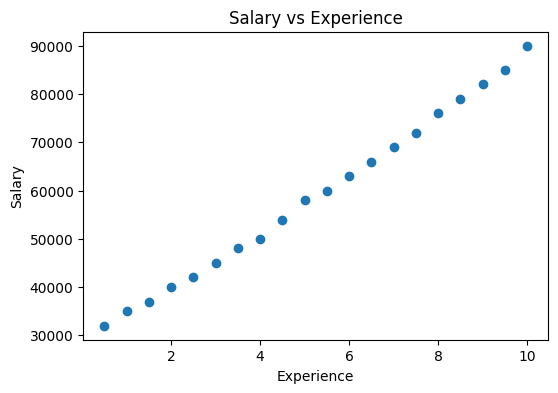

In [7]:
#Scatter plot to visualise the data
plt.figure(figsize=(6,4))
plt.scatter(df["Experience"],df["Salary"])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

In [16]:
#Split the features into Target and input
X = df[["Experience"]]
y = df["Salary"]
print(X)

    Experience
0          0.5
1          1.0
2          1.5
3          2.0
4          2.5
5          3.0
6          3.5
7          4.0
8          4.5
9          5.0
10         5.5
11         6.0
12         6.5
13         7.0
14         7.5
15         8.0
16         8.5
17         9.0
18         9.5
19        10.0


In [17]:
print(y)

0     32000
1     35000
2     37000
3     40000
4     42000
5     45000
6     48000
7     50000
8     54000
9     58000
10    60000
11    63000
12    66000
13    69000
14    72000
15    76000
16    79000
17    82000
18    85000
19    90000
Name: Salary, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
#Model Parameters 
print("Slope obtained for the model: ",model.coef_)
print("Intercept: ",model.intercept_)

Slope obtained for the model:  [6141.45679385]
Intercept:  26672.749208264213


In [22]:
#Predictions
y_pred = model.predict(X_test)

#Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))

MAE:  1173.0131201930371
MSE:  2477694.4471502006
R2 Score:  0.995264232331334


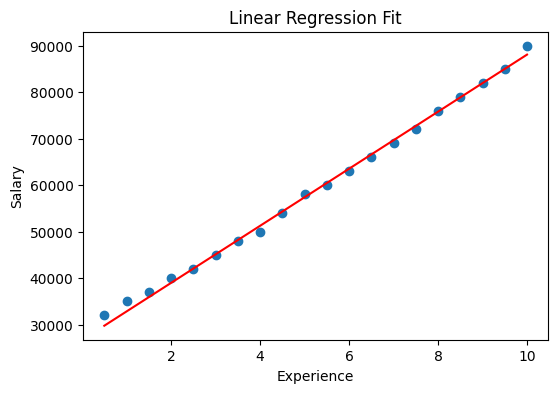

In [23]:
#Plot Regression Line
plt.figure(figsize=(6,4))
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Fit")
plt.show()

In [24]:
#Predict salary for 7 years experience
result = model.predict([[7]])
print(f"The salary for a person with 7 years experience is {result}")

The salary for a person with 7 years experience is [69662.94676519]


C:\Users\manan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
